# Standard Problem for Ferromagnetic Resonance Simulation

## Google Colab Link

The demo can be run on Google Colab without any local installation.
Use the following [link](https://colab.research.google.com/drive/160QXXUkDEpd-GvZyI2PhLIdnSIDRVyG0) to try out.

## Install magnum.np and download reference data if not available

In [1]:
!pip install -q magnumnp numpy==1.22.4

In [2]:
from os import path
if not path.isdir("ref"):
    !mkdir ref
    !wget -P ref https://gitlab.com/nina_sturm/magnum.np/raw/main/demos/sp_FMR/ref/m_ref.dat

## Run Demo:

In [ ]:
from magnumnp import *
import torch
from math import sin, cos, pi

Timer.enable()

# initialize mesh
eps = 1e-15
n = (24, 24, 2)
l = (120e-9, 120e-9, 10e-9)
dx = (l[0]/n[0], l[1]/n[1], l[2]/n[2])
origin = (-n[0]*dx[0]/2., -n[1]*dx[1]/2., -n[2]*dx[2]/2.)
mesh = Mesh(n, dx, origin=origin)

# initialize state
state = State(mesh)
state.material = {
    "alpha": 1.,
    "Ms": 800e3,
    "A": 13e-12
    }
state.m = state.Constant([0, 0, 1])

#relax state
demag    = DemagField()
exchange = ExchangeField()
bias     = ExternalField(80e3*state.Tensor([1., 0.715, 0]).normalize())

llg = LLGSolver([demag, exchange, bias])
llg.relax(state)
write_vti(state.m, "data/m0.vti")

#integrate
state.t = 0.0
state.material["alpha"] = 0.008 
bias = ExternalField(80e3*state.Tensor([1., 0.7, 0]).normalize())

llg = LLGSolver([demag, exchange, bias])
logger = Logger("data", ['t', 'm'], ["m"])
while state.t < 10e-9-eps:
    llg.step(state, 5e-12)
    logger << state

Timer.print_report()


## Plot Results

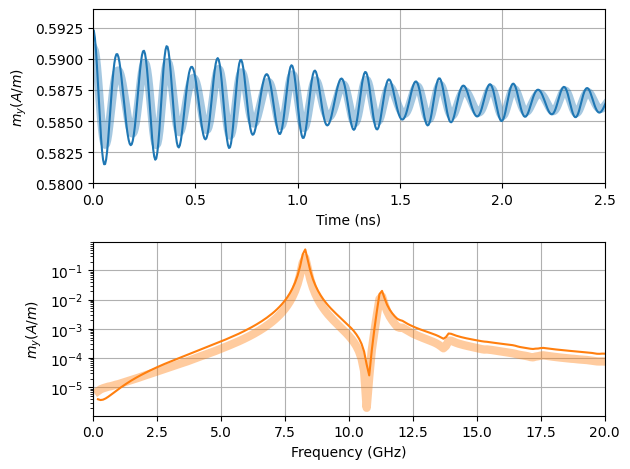

In [5]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("data/log.dat")
data_ref = np.loadtxt("ref/m_ref.dat")

t, mx, my, mz = data.T
t_ref, mx_ref, my_ref, mz_ref = data_ref.T

sy = abs((np.fft.fft(my)**2.))
sy_ref = abs((np.fft.fft(my_ref)**2.))
f = np.fft.fftfreq(len(t), t[1]-t[0])*1e-9
f_ref = np.fft.fftfreq(len(t_ref), t_ref[1]-t_ref[0])*1e-9


fig, (ax0, ax1) = plt.subplots(2,1)
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax0.plot(t*1e9, my, color=cycle[0])
ax0.plot(t_ref*1e9, my_ref, '-', color=cycle[0], linewidth=6, alpha=0.4)
ax0.set_xlabel("Time (ns)")
ax0.set_ylabel("$m_y (A/m)$")
ax0.set_xlim(0, 2.5)
ax0.set_ylim(0.580, 0.594)
ax0.grid()

ax1.plot(f[2: -len(f)//2], sy[2: -len(f)//2], '-', color=cycle[1])
ax1.plot(f_ref[2: -len(f_ref)//2], sy_ref[2: -len(f_ref)//2], '-', color=cycle[1], linewidth=6, alpha=0.4)
ax1.set_yscale("log")
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("$m_y (A/m)$")
ax1.set_xlim(0, 20)
ax1.grid()
fig.tight_layout()
fig.savefig("data/results.png")